# ML

### Preliminaries

##### Packages

In [21]:
def warn(*args, **kwargs):
    pass
import warnings
warnings.warn = warn

import pandas as pd
import numpy as np
import random
from itertools import product
from operator import itemgetter
import matplotlib.pyplot as plt
from scipy.stats import norm

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import RandomForestClassifier

random.seed(123)

##### Printing Objects

In [2]:
def stringify(res): # Takes in a result object of { 'score': int, ['options': values] }
    iterated_keys = list(set(res.keys()) - set(['score']))
    specs_string = f'({', '.join([str(res[x]) for x in iterated_keys])})'
    return f'{specs_string}; score: {res['score']}'

### Dataset

In [3]:
df = pd.read_csv('hie_dataset.csv')
df

,country,year,"GNI per capita, Atlas method (current US$)","Population, total",Surface area (sq. km),Population living in slums (% of urban population),hie,near_2_plus_oceans,border_count,size
0,Albania,2000,1130.0,3089027.0,28750.0,28.10000,False,False,4.0,small
1,Angola,2000,360.0,16194869.0,1246700.0,19.70000,False,False,4.0,large
2,Argentina,2000,7400.0,37213984.0,2780400.0,20.29188,False,True,5.0,large
3,Armenia,2000,630.0,3221100.0,29740.0,12.79599,False,False,4.0,small
4,Aruba,2000,20060.0,90588.0,180.0,0.00000,True,False,0.0,small
...,...,...,...,...,...,...,...,...,...,...
1897,Vanuatu,2022,3830.0,313046.0,12190.0,3.06400,False,False,0.0,small
1898,Venezuela,2022,2260.0,28213017.0,912050.0,25.70000,False,False,3.0,medium
1899,Vietnam,2022,3980.0,99680655.0,331340.0,32.50000,False,False,3.0,large
1900,Zambia,2022,1170.0,20152938.0,752610.0,48.25813,False,False,8.0,medium


### Data
60, 20, 20 split

In [4]:
x_overall = df[['year', "Population living in slums (% of urban population)", 'near_2_plus_oceans', 'border_count', 'size']]
y = df[['hie']]
one_hot = pd.get_dummies(x_overall['size'])
x_overall = x_overall.drop('size', axis = 1)
x_overall = x_overall.join(one_hot)
X_train, X_test_val, y_train, y_test_val = train_test_split(x_overall, y, test_size = 0.4, random_state = 123)
X_test, X_valid, y_test, y_valid = train_test_split(X_test_val, y_test_val, test_size = 0.5, random_state = 123)

### AdaBoosting

In [5]:
options = { 'criterion': ['gini', 'entropy'], 'max-depth': [1, 3, 5, 7], 'learning-rate': [0.8, 1.0, 1.2] }
keys, values = zip(*options.items())
option_combos = [dict(zip(keys, p)) for p in product(*values)]

results = []
for combo in option_combos:
    # Training
    estimator = DecisionTreeClassifier(criterion = combo['criterion'], max_depth = combo['max-depth'], random_state = 123)
    clf = AdaBoostClassifier(estimator = estimator, n_estimators = 100, random_state = 0, learning_rate = combo['learning-rate'])
    clf.fit(X_train, y_train.values.ravel())
    
    # Cross Validation (Holdout)
    score = clf.score(X_valid, y_valid)
    res = { 'score': round(score, 3), 'criterion': combo['criterion'], 'max-depth': combo['max-depth'], 'learning-rate': combo['learning-rate'] }
    results.append(res)
    print(f'Training: {stringify(res)}')

sorted_results = sorted(results, key = lambda d: d['score'], reverse = True)
print(f'Best Valid.: {stringify(sorted_results[0])}')

# Training the Final Model and Testing
final_estimator = DecisionTreeClassifier(criterion = sorted_results[0]['criterion'], max_depth = sorted_results[0]['max-depth'], random_state = 123)
final_clf = AdaBoostClassifier(estimator = estimator, n_estimators = 100, random_state = 0, learning_rate = sorted_results[0]['learning-rate'])
final_clf.fit(pd.concat([X_train, X_valid]), pd.concat([y_train, y_valid]).values.ravel())
final_score = final_clf.score(X_test, y_test) # type: ignore
final_res = { 'score': round(final_score, 3), 'criterion': sorted_results[0]['criterion'], 'max-depth': sorted_results[0]['max-depth'], 'learning-rate': sorted_results[0]['learning-rate'] }
print(f'Final: {stringify(final_res)}')

Training: (gini, 0.8, 1); score: 0.921
Training: (gini, 1.0, 1); score: 0.927
Training: (gini, 1.2, 1); score: 0.929
Training: (gini, 0.8, 3); score: 0.919
Training: (gini, 1.0, 3); score: 0.942
Training: (gini, 1.2, 3); score: 0.94
Training: (gini, 0.8, 5); score: 0.95
Training: (gini, 1.0, 5); score: 0.929
Training: (gini, 1.2, 5); score: 0.937
Training: (gini, 0.8, 7); score: 0.937
Training: (gini, 1.0, 7); score: 0.934
Training: (gini, 1.2, 7); score: 0.934
Training: (entropy, 0.8, 1); score: 0.924
Training: (entropy, 1.0, 1); score: 0.924
Training: (entropy, 1.2, 1); score: 0.924
Training: (entropy, 0.8, 3); score: 0.924
Training: (entropy, 1.0, 3); score: 0.94
Training: (entropy, 1.2, 3); score: 0.932
Training: (entropy, 0.8, 5); score: 0.94
Training: (entropy, 1.0, 5); score: 0.94
Training: (entropy, 1.2, 5); score: 0.937
Training: (entropy, 0.8, 7); score: 0.948
Training: (entropy, 1.0, 7); score: 0.942
Training: (entropy, 1.2, 7); score: 0.937
Best Valid.: (gini, 0.8, 5); scor

### Gradient Boosting

In [6]:
options = { 'loss': ['log_loss', 'exponential'], 'learning-rate': [0.05, 0.1, 0.15, 0.2], 'max-depth': [1, 3, 5, 7] }
keys, values = zip(*options.items())
option_combos = [dict(zip(keys, p)) for p in product(*values)]

results = []
for combo in option_combos:
    # Training
    clf = GradientBoostingClassifier(loss = combo['loss'], learning_rate = combo['learning-rate'], max_depth = combo['max-depth'], random_state = 123)
    clf.fit(X_train, y_train.values.ravel())
    
    # Cross Validation (Holdout)
    score = clf.score(X_valid, y_valid)
    res = { 'score': round(score, 3), 'loss': combo['loss'], 'max-depth': combo['max-depth'], 'learning-rate': combo['learning-rate'] }
    results.append(res)
    print(f'Training: {stringify(res)}')


sorted_results = sorted(results, key = lambda d: d['score'], reverse = True)
print(f'Best Valid.: {stringify(sorted_results[0])}')

# Training the Final Model and Testing
final_clf = GradientBoostingClassifier(loss = sorted_results[0]['loss'], learning_rate = sorted_results[0]['learning-rate'], max_depth = sorted_results[0]['max-depth'], random_state = 123)
final_clf.fit(pd.concat([X_train, X_valid]), pd.concat([y_train, y_valid]).values.ravel())
final_score = final_clf.score(X_test, y_test) # type: ignore
final_res = { 'score': round(final_score, 3), 'loss': sorted_results[0]['loss'], 'max-depth': sorted_results[0]['max-depth'], 'learning-rate': sorted_results[0]['learning-rate'] }
print(f'Final: {stringify(final_res)}')

Training: (0.05, log_loss, 1); score: 0.919
Training: (0.05, log_loss, 3); score: 0.937
Training: (0.05, log_loss, 5); score: 0.942
Training: (0.05, log_loss, 7); score: 0.932
Training: (0.1, log_loss, 1); score: 0.919
Training: (0.1, log_loss, 3); score: 0.942
Training: (0.1, log_loss, 5); score: 0.932
Training: (0.1, log_loss, 7); score: 0.937
Training: (0.15, log_loss, 1); score: 0.927
Training: (0.15, log_loss, 3); score: 0.937
Training: (0.15, log_loss, 5); score: 0.932
Training: (0.15, log_loss, 7); score: 0.942
Training: (0.2, log_loss, 1); score: 0.927
Training: (0.2, log_loss, 3); score: 0.94
Training: (0.2, log_loss, 5); score: 0.937
Training: (0.2, log_loss, 7); score: 0.932
Training: (0.05, exponential, 1); score: 0.919
Training: (0.05, exponential, 3); score: 0.937
Training: (0.05, exponential, 5); score: 0.937
Training: (0.05, exponential, 7); score: 0.945
Training: (0.1, exponential, 1); score: 0.919
Training: (0.1, exponential, 3); score: 0.942
Training: (0.1, exponenti

### Random Forest

In [7]:
options = { 'criterion': ['gini', 'entropy', 'log_loss'], 'max-depth': [2, 4, 6, 8], 'max-features': ['sqrt', 'log2', None] }
keys, values = zip(*options.items())
option_combos = [dict(zip(keys, p)) for p in product(*values)]

results = []
for combo in option_combos:
    # Training
    clf = RandomForestClassifier(criterion = combo['criterion'], max_depth = combo['max-depth'], max_features = combo['max-features'], random_state = 123)
    clf.fit(X_train, y_train.values.ravel())
    
    # Cross Validation (Holdout)
    score = clf.score(X_valid, y_valid)
    res = { 'score': round(score, 3), 'criterion': combo['criterion'], 'max-depth': combo['max-depth'], 'max-features': combo['max-features'] }
    results.append(res)
    print(stringify(res))

sorted_results = sorted(results, key = lambda d: d['score'], reverse = True)
print(f'Best Valid.: {stringify(sorted_results[0])}')

# Training the Final Model and Testing
final_clf = RandomForestClassifier(criterion = sorted_results[0]['criterion'], max_depth = sorted_results[0]['max-depth'], max_features = sorted_results[0]['max-features'], random_state = 123)
final_clf.fit(pd.concat([X_train, X_valid]), pd.concat([y_train, y_valid]).values.ravel())
final_score = final_clf.score(X_test, y_test) # type: ignore
final_res = { 'score': round(final_score, 3), 'criterion': sorted_results[0]['criterion'], 'max-depth': sorted_results[0]['max-depth'], 'max_features': sorted_results[0]['max-features'] }
print(f'Final: {stringify(final_res)}')

(gini, 2, sqrt); score: 0.916
(gini, 2, log2); score: 0.916
(gini, 2, None); score: 0.919
(gini, 4, sqrt); score: 0.919
(gini, 4, log2); score: 0.919
(gini, 4, None); score: 0.921
(gini, 6, sqrt); score: 0.924
(gini, 6, log2); score: 0.924
(gini, 6, None); score: 0.94
(gini, 8, sqrt); score: 0.932
(gini, 8, log2); score: 0.932
(gini, 8, None); score: 0.934
(entropy, 2, sqrt); score: 0.919
(entropy, 2, log2); score: 0.919
(entropy, 2, None); score: 0.919
(entropy, 4, sqrt); score: 0.919
(entropy, 4, log2); score: 0.919
(entropy, 4, None); score: 0.919
(entropy, 6, sqrt); score: 0.924
(entropy, 6, log2); score: 0.924
(entropy, 6, None); score: 0.932
(entropy, 8, sqrt); score: 0.927
(entropy, 8, log2); score: 0.927
(entropy, 8, None); score: 0.932
(log_loss, 2, sqrt); score: 0.919
(log_loss, 2, log2); score: 0.919
(log_loss, 2, None); score: 0.919
(log_loss, 4, sqrt); score: 0.919
(log_loss, 4, log2); score: 0.919
(log_loss, 4, None); score: 0.919
(log_loss, 6, sqrt); score: 0.924
(log_lo

### Now Testing Cross Validation
##### Generating Confidence Interval Graph

In [71]:
def gen_CI(mean, std):
    ax = np.arange(mean - 4 * std, mean + 4 * std, 0.0001)
    plt.plot(ax, norm.pdf(ax, mean, std))
    plt.axvline(mean, 0, 0.95, linestyle = 'dashed')
    # plt.axhline(1, mean - 2 * std, mean - std)
    plt.text(mean + 0.003, 0, f'mu = {round(mean, 3)}', rotation = 0)
    plt.text(mean + 2 * std, 3, f'sigma = {round(std, 3)}', rotation = 0)

    x_CIs = []
    for alpha in [0.9, 0.95, 0.99]:
        x_CIs.extend(norm.interval(alpha, loc = mean, scale = std))
    x_CIs = np.array(x_CIs)
    y_points = np.array([0] * 6)
    plt.plot(x_CIs, y_points, 'o')
    plt.show()

##### Testing the CV with the Holdout-Optimal Random Forest

Mean: 0.939, Std: 0.023


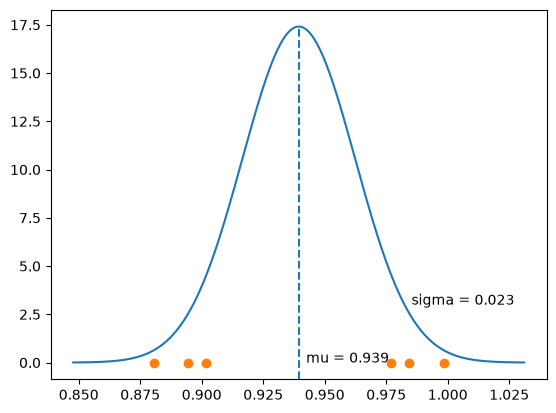

In [75]:
clf = RandomForestClassifier(criterion = 'gini', max_depth = 6, max_features = None, random_state = 123)
scores = cross_val_score(clf, x_overall, y, cv = 30) # For CLT Normality
print(f'Mean: {round(scores.mean(), 3)}, Std: {round(scores.std(), 3)}')

gen_CI(scores.mean(), scores.std())